# Logistic Regression (Логистическая регрессия)

Применение алгоритма Логистическая регрессия для решения задачи классификации.


### Датасет
**Цветки Ириса**

Датасет содержит 150 записей, каждая из записей содержит 4 признака.

Признаки:

1. длина чашелистника, см
2. ширина чашелистника, см
3. длина лепестка, см
4. ширина лепестка, см

Метки классов:

1. Setosa
2. Versicolour
3. Virginica

## 0. Импорт библиотек


In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from sklearn import datasets

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import pandas as pd
import numpy as np

## 1. Загружаем данные по цветкам ирисов

Для этого воспользуемся встроенным в библиотеке `scikit-learn` модулем `datasets`

In [2]:
iris = datasets.load_iris()

In [3]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [4]:
# Информация по признакам
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [5]:
# Информация по целевой переменной
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [6]:
# Проверка размерности датасета и целевой переменной
print('Размерность признакового пространства {}'.format(iris.data.shape))
print('Размерность вектора целевой переменной {}'.format(iris.target.shape))

Размерность признакового пространства (150, 4)
Размерность вектора целевой переменной (150,)


In [7]:
X = iris.data[:, :4]
y = iris.target

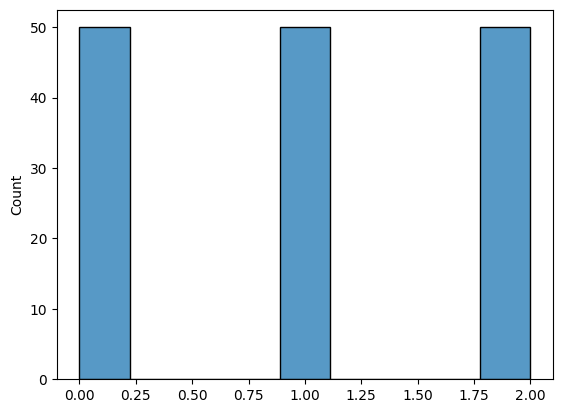

In [8]:
# Гистограмма распределения целевой переменной
sns.histplot(y);

## Матрица Корреляций



In [9]:
iris_df = pd.DataFrame(np.c_[iris.data, iris.target], columns=['sepal length (cm)',
                                                               'sepal width (cm)',
                                                               'petal length (cm)',
                                                               'petal width (cm)',
                                                               'class'])

corr_matrix = iris_df.corr()
print(corr_matrix)

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   
class                       0.782561         -0.426658           0.949035   

                   petal width (cm)     class  
sepal length (cm)          0.817941  0.782561  
sepal width (cm)          -0.366126 -0.426658  
petal length (cm)          0.962865  0.949035  
petal width (cm)           1.000000  0.956547  
class                      0.956547  1.000000  


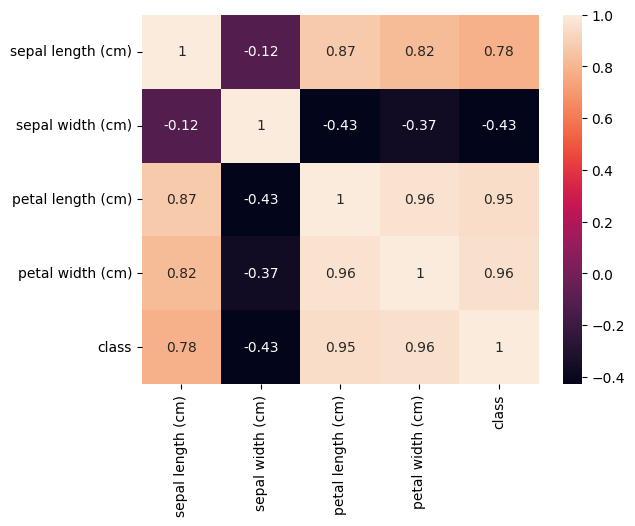

In [10]:
# Визуализация матрицы корреляций
sns.heatmap(corr_matrix, annot=True);

# 2. Обучение модели

In [11]:
# Разбиение на тестовую и обучающую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [12]:
classifier_LR = LogisticRegression(random_state=21, max_iter=1000)

classifier_LR.fit(X_train, y_train)

# Прогноз
y_pred = classifier_LR.predict(X_test)

In [13]:
classifier_LR.coef_

array([[-0.41360574,  0.84866329, -2.33208281, -0.98859015],
       [ 0.51464691, -0.2966476 , -0.21718957, -0.71439614],
       [-0.10104117, -0.55201569,  2.54927238,  1.70298629]])

In [14]:
# Точность модели
print('Точность: {:.2f}'.format(classifier_LR.score(X_test, y_test)))

Точность: 0.97


# 3. Подбор параметров модели

In [15]:
from sklearn.model_selection import GridSearchCV

# параметры для перебора
parameters = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2']
}

# создадим объект модели
classifier_logreg = LogisticRegression(
    random_state=21,
    max_iter=10000,
    solver='saga'
)
# Перебор параметров
clf=GridSearchCV(classifier_logreg, param_grid=parameters, cv=3)

# обучение модели по сетке гиперпараметров
clf.fit(X_train,y_train)

GridSearchCV(cv=3,
             estimator=LogisticRegression(max_iter=10000, random_state=21,
                                          solver='saga'),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10],
                         'penalty': ['l1', 'l2']})

In [16]:
# Лучшие параметры
print(clf.best_params_)

# Лучшая точность
print("Точность :",round(clf.best_score_, 2))

{'C': 10, 'penalty': 'l2'}
Точность : 0.98


In [17]:
# Коэффициенты для лучшей модели
print(np.sum(clf.best_estimator_== 0), clf.best_estimator_.coef_, sep = '\n')

0
[[ 1.34857095  2.71291377 -3.95204667 -1.89856629]
 [ 0.98260538 -0.17247143 -0.57977695 -1.5276955 ]
 [-2.33117633 -2.54044235  4.53182362  3.42626179]]
